C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


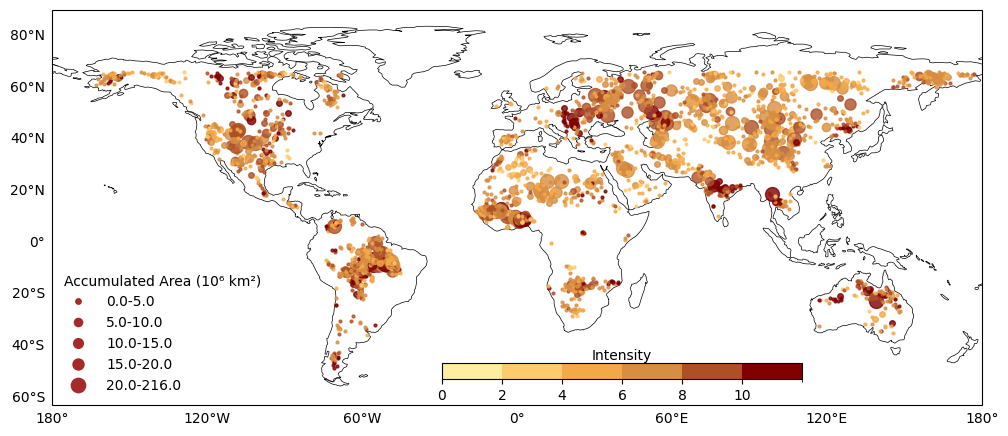

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CHDW_Oberv_Accumulatedarea_Intensity_1_1.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CHDW_Oberv_Accumulatedarea_Intensity_1_1.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CHDW_Oberv_Accumulatedarea_Intensity_1_1.svg


In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable

file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Event_Level_Summary.xlsx"

save_directory = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots"
os.makedirs(save_directory, exist_ok=True)

out_png = os.path.join(
    save_directory,
    "CHDW_Oberv_Accumulatedarea_Intensity_1_1.png"
)

out_pdf = os.path.join(
    save_directory,
    "CHDW_Oberv_Accumulatedarea_Intensity_1_1.pdf"
)

out_svg = os.path.join(
    save_directory,
    "CHDW_Oberv_Accumulatedarea_Intensity_1_1.svg"
)

data = pd.read_excel(file_path)

fixed_intervals = [0, 2, 4, 6, 8, 10, 30]

colors = [
    "#ffeda0",
    "#feb24c",
    "#cd853f",
    "#800000"
]

cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    colors,
    N=len(fixed_intervals) - 1
)

norm = mcolors.BoundaryNorm(
    fixed_intervals,
    cmap.N
)

def get_circle_size(voxels):
    if voxels <= 100:
        return 2
    elif voxels <= 200:
        return 4
    elif voxels <= 300:
        return 6
    elif voxels <= 400:
        return 8
    else:
        return 10

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

ax.coastlines(
    resolution="110m",
    linewidth=0.5
)

ax.set_extent(
    [-180, 180, -63, 90],
    crs=ccrs.PlateCarree()
)

for _, row in data.iterrows():

    color = cmap(
        norm(row["Intensity"])
    )

    size = get_circle_size(
        row["Total Voxels"]
    )

    ax.plot(
        row["Longitude"],
        row["Latitude"],
        "o",
        color=color,
        markersize=size,
        alpha=0.8,
        transform=ccrs.Geodetic()
    )

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color="gray",
    alpha=0.7
)

gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

colorbar_ax = fig.add_axes(
    [0.45, 0.28, 0.30, 0.02]
)

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=colorbar_ax,
    orientation="horizontal"
)

cbar.set_ticks(
    [0, 2, 4, 6, 8, 10]
)

cbar.set_ticklabels(
    ["0", "2", "4", "6", "8", "10"]
)

cbar.set_label(
    "Intensity",
    rotation=0,
    labelpad=-39,
    horizontalalignment="center"
)

labels = [
    "0.0-5.0",
    "5.0-10.0",
    "10.0-15.0",
    "15.0-20.0",
    "20.0-216.0"
]

legend_sizes = [
    1.5,
    3,
    4,
    5,
    8
]

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color="none",
        markerfacecolor="brown",
        markeredgecolor="none",
        markersize=np.sqrt(size) * 4,
        label=label
    )
    for size, label in zip(
        legend_sizes,
        labels
    )
]

legend = ax.legend(
    handles=handles,
    title="Accumulated Area (10⁶ km²)",
    title_fontsize=10,
    fontsize=10,
    loc="lower left",
    frameon=False,
    handlelength=2,
    handletextpad=1
)

legend._legend_box.align = "left"

fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

Total number of events: 2584

Percentage of events in each category:
Area Category
0.0-5.0     80.572755
5.0-10.0    11.493808
>10          7.933437
Name: count, dtype: float64


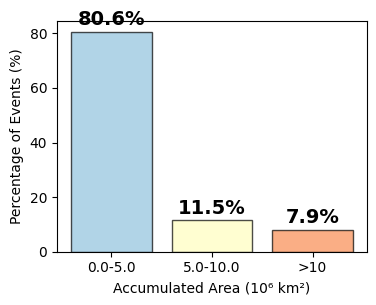

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Event_Level_Summary.xlsx"
data = pd.read_excel(file_path)

bins = [0, 5, 10, float('inf')]
labels = ['0.0-5.0', '5.0-10.0', '>10']


data['Area Category'] = pd.cut(data['Accumulated_Area'], bins=bins, labels=labels, include_lowest=True)

category_counts = data['Area Category'].value_counts().sort_index()

category_percentages = (category_counts / category_counts.sum()) * 100

total_events = data.shape[0]
print(f"Total number of events: {total_events}")
print("\nPercentage of events in each category:")
print(category_percentages)

plt.figure(figsize=(4, 3))
colors = sns.color_palette("RdYlBu_r", len(category_percentages))
bars = plt.bar(category_percentages.index, category_percentages, color=colors, edgecolor='black', alpha=0.7)

for bar, percentage in zip(bars, category_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.xlabel('Accumulated Area (10⁶ km²)')
plt.ylabel('Percentage of Events (%)')
plt.xticks(rotation=0)
plt.show()


Total number of events: 2572

Percentage of events in each category for each continent:
Area Category    0.0-5.0   5.0-10.0       >10
Continent                                    
Africa         81.316726  11.209964  7.473310
Eurasia        77.606178  12.451737  9.942085
North America  85.106383  10.638298  4.255319
Oceania        90.625000   7.291667  2.083333
South America  79.780220  11.428571  8.791209


C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\3834107059.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  continent_category_counts = gdf_events.groupby(['Continent', 'Area Category']).size().unstack(fill_value=0)


<Figure size 1000x600 with 0 Axes>

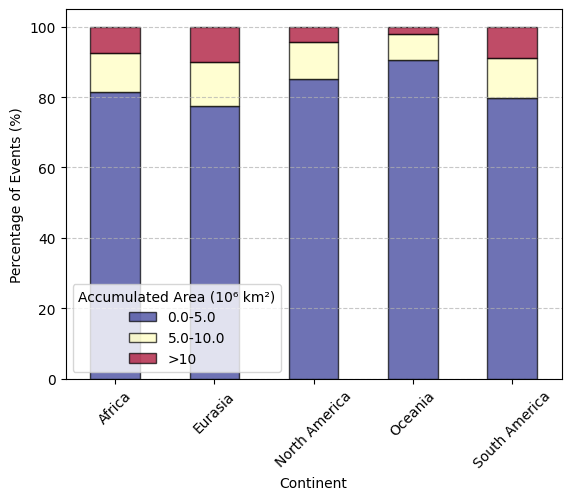

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Event_Level_Summary.xlsx"
data = pd.read_excel(file_path)

gdf_events = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['Longitude'], data['Latitude']), crs="EPSG:4326")


shapefile_folder = "D:\PhD_Research\Paper-3_CHDW_Migration\Data\World_Continents"

continents = ["Africa", "Asia", "Europe", "North America", "Oceania", "South America"]


gdf_events['Continent'] = None

for continent in continents:
    continent_shapefile = f"{shapefile_folder}\{continent}.shp"

    gdf_continent = gpd.read_file(continent_shapefile)
    

    gdf_events.loc[gdf_events.sjoin(gdf_continent, predicate='within').index, 'Continent'] = continent


gdf_events['Continent'] = gdf_events['Continent'].replace({'Europe': 'Eurasia', 'Asia': 'Eurasia'})


gdf_events = gdf_events.dropna(subset=['Continent'])


bins = [0, 5, 10, float('inf')]
labels = ['0.0-5.0', '5.0-10.0', '>10']


gdf_events['Area Category'] = pd.cut(gdf_events['Accumulated_Area'], bins=bins, labels=labels, include_lowest=True)


continent_category_counts = gdf_events.groupby(['Continent', 'Area Category']).size().unstack(fill_value=0)
continent_category_percentages = continent_category_counts.div(continent_category_counts.sum(axis=1), axis=0) * 100

total_events = gdf_events.shape[0]
print(f"Total number of events: {total_events}")
print("\nPercentage of events in each category for each continent:")
print(continent_category_percentages)

plt.figure(figsize=(10, 6))
continent_category_percentages.plot(kind='bar', stacked=True, colormap='RdYlBu_r', edgecolor='black', alpha=0.7)
plt.xlabel('Continent')
plt.ylabel('Percentage of Events (%)')
plt.xticks(rotation=45)
plt.legend(title='Accumulated Area (10⁶ km²)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


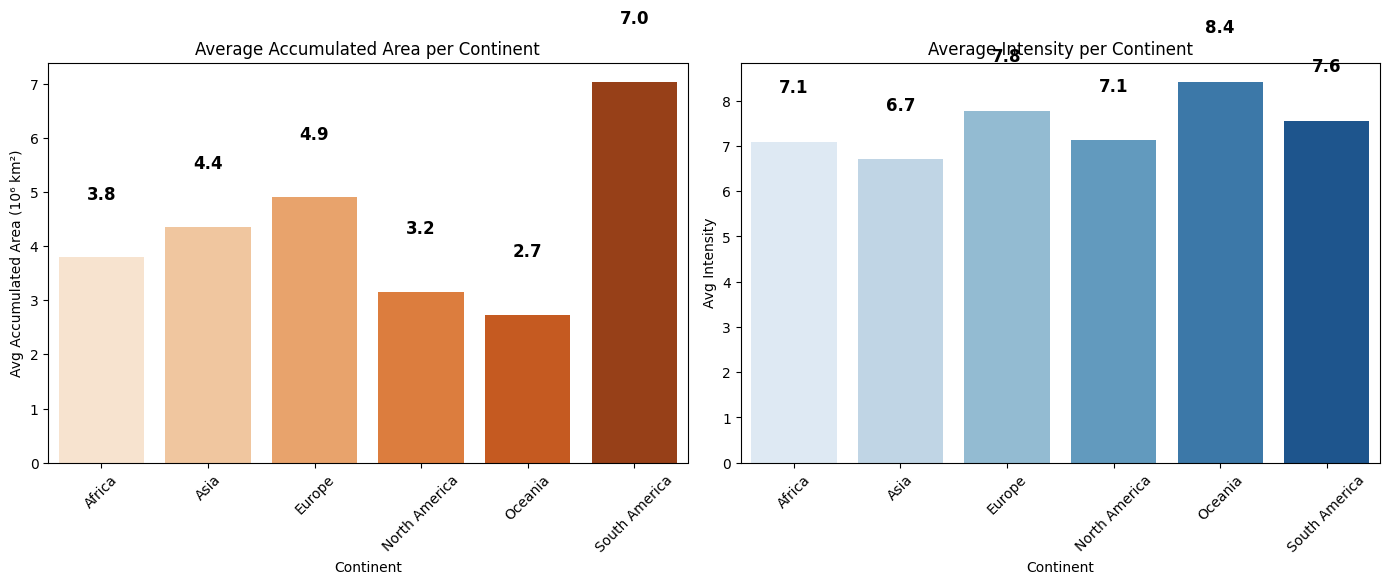

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Event_Level_Summary.xlsx"
data = pd.read_excel(file_path)

gdf_events = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['Longitude'], data['Latitude']), crs="EPSG:4326")


shapefile_folder = "D:\\PhD_Research\\Paper-3_CHDW_Migration\\Data\\World_Continents"


continents = ["Africa", "Asia", "Europe", "North America", "Oceania", "South America"]


gdf_events['Continent'] = None


for continent in continents:
    continent_shapefile = f"{shapefile_folder}\\{continent}.shp"
    

    gdf_continent = gpd.read_file(continent_shapefile)
    

    gdf_events.loc[gdf_events.sjoin(gdf_continent, predicate='within').index, 'Continent'] = continent

gdf_events = gdf_events.dropna(subset=['Continent'])


avg_accumulated_area = gdf_events.groupby('Continent')['Accumulated_Area'].mean()
avg_intensity = gdf_events.groupby('Continent')['Intensity'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(x=avg_accumulated_area.index, y=avg_accumulated_area.values, palette="Oranges", ax=axes[0])
axes[0].set_title("Average Accumulated Area per Continent")
axes[0].set_xlabel("Continent")
axes[0].set_ylabel("Avg Accumulated Area (10⁶ km²)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

for bar, value in zip(axes[0].patches, avg_accumulated_area.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

sns.barplot(x=avg_intensity.index, y=avg_intensity.values, palette="Blues", ax=axes[1])
axes[1].set_title("Average Intensity per Continent")
axes[1].set_xlabel("Continent")
axes[1].set_ylabel("Avg Intensity")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

for bar, value in zip(axes[1].patches, avg_intensity.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\991339348.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('lat_bin').agg({


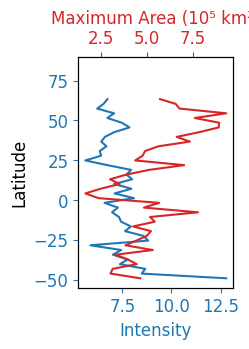

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


file_path = 'D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Event_Level_Summary.xlsx'
data = pd.read_excel(file_path)


lat_bins = np.linspace(-55, 90, num=50) 
data['lat_bin'] = pd.cut(data['Latitude'], bins=lat_bins, labels=lat_bins[:-1])

grouped = data.groupby('lat_bin').agg({
    'Intensity': 'mean',
    'Maximum_Area': 'mean'
}).reset_index()

grouped['lat_bin'] = grouped['lat_bin'].astype(float)


fig, ax1 = plt.subplots(figsize=(2, 3))  

ax1.set_xlabel('Intensity', fontsize=12, color='tab:blue')
ax1.set_ylabel('Latitude', fontsize=12)
ax1.plot(grouped['Intensity'], grouped['lat_bin'], color='tab:blue', linewidth=1.5)
ax1.tick_params(axis='both', labelsize=12, colors='tab:blue')
ax1.set_ylim(-55, 90)  

ax2 = ax1.twiny()
ax2.set_xlabel('Maximum Area (10⁵ km²)', fontsize=12, color='tab:red')
ax2.plot(grouped['Maximum_Area'], grouped['lat_bin'], color='tab:red', linewidth=1.5)
ax2.tick_params(axis='x', labelsize=12, colors='tab:red')


high_res_png = 'D:\\PhD_Research\\Paper-3_CHDW_Migration\\Results\\Plots\\Latitude_Variation_Accumulatedarea_Intensity.png'
plt.savefig(high_res_png, dpi=600, bbox_inches='tight', transparent=True)
plt.show()


C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


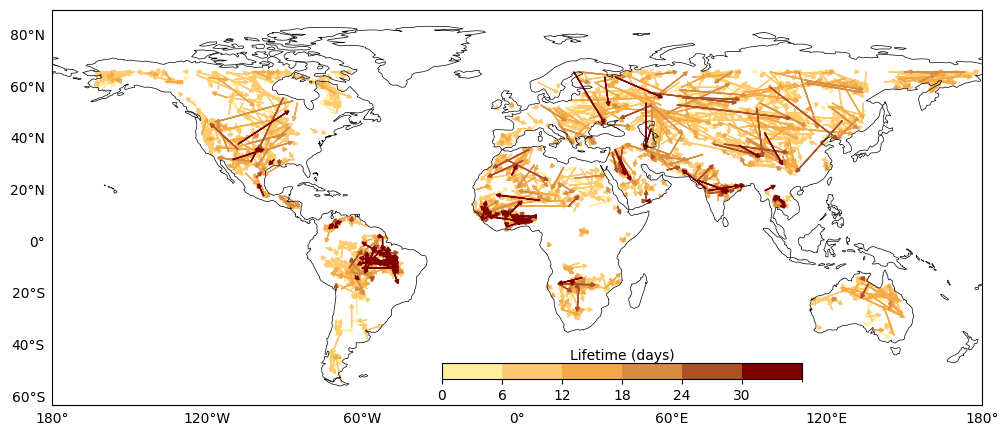

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CHDW_Oberv_Accumulatedarea_Intensity_2_1.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CHDW_Oberv_Accumulatedarea_Intensity_2_1.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CHDW_Oberv_Accumulatedarea_Intensity_2_1.svg


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap


file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Event_Displacement_Summary.xlsx"

save_directory = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots"
os.makedirs(save_directory, exist_ok=True)

out_png = os.path.join(
    save_directory,
    "CHDW_Oberv_Accumulatedarea_Intensity_2_1.png"
)

out_pdf = os.path.join(
    save_directory,
    "CHDW_Oberv_Accumulatedarea_Intensity_2_1.pdf"
)

out_svg = os.path.join(
    save_directory,
    "CHDW_Oberv_Accumulatedarea_Intensity_2_1.svg"
)


df = pd.read_excel(file_path)

colors = [
    "#ffeda0",
    "#feb24c",
    "#cd853f",
    "#800000"
]

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    colors,
    N=256
)

max_duration = df["Duration"].max()

bounds = np.array([
    0,
    6,
    12,
    18,
    24,
    30,
    max_duration
], dtype=float)

if max_duration <= 30:
    bounds[-1] = 30.01

norm = mcolors.BoundaryNorm(
    bounds,
    custom_cmap.N
)

df_sorted = df.sort_values(
    by="Duration"
)

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

ax.coastlines(
    resolution="110m",
    linewidth=0.5
)

ax.set_extent(
    [-180, 180, -63, 90],
    crs=ccrs.PlateCarree()
)

for _, row in df_sorted.iterrows():

    color = custom_cmap(
        norm(row["Duration"])
    )

    ax.arrow(
        row["Starting Longitude"],
        row["Starting Latitude"],
        row["Ending Longitude"] - row["Starting Longitude"],
        row["Ending Latitude"] - row["Starting Latitude"],
        color=color,
        alpha=1.0,
        transform=ccrs.PlateCarree(),
        width=0.05,
        head_width=1.5,
        head_length=1.5,
        length_includes_head=True
    )

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color="gray",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

colorbar_ax = fig.add_axes(
    [0.45, 0.28, 0.30, 0.02]
)

sm = plt.cm.ScalarMappable(
    cmap=custom_cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=colorbar_ax,
    orientation="horizontal"
)

cbar.set_ticks(
    [0, 6, 12, 18, 24, 30]
)

cbar.set_ticklabels(
    ["0", "6", "12", "18", "24", "30"]
)

cbar.set_label(
    "Lifetime (days)",
    rotation=0,
    labelpad=-39,
    horizontalalignment="center"
)

fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

Total number of events: 2460

Percentage of events in each category:
Displacement Category
0-500       69.878049
500-1000    21.138211
>1000        8.983740
Name: count, dtype: float64


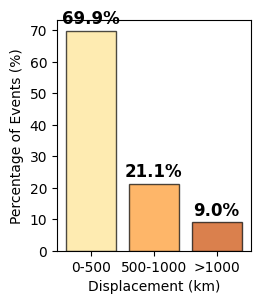

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Temporal_Events_Summary.xlsx"
data = pd.read_excel(file_path)

bins = [0, 500, 1000, float('inf')]
labels = ['0-500', '500-1000', '>1000']

data['Displacement Category'] = pd.cut(data['Distance'], bins=bins, labels=labels, include_lowest=True)

category_counts = data['Displacement Category'].value_counts().sort_index()

category_percentages = (category_counts / category_counts.sum()) * 100

total_events = data.shape[0]
print(f"Total number of events: {total_events}")
print("\nPercentage of events in each category:")
print(category_percentages)

plt.figure(figsize=(2.5, 3))
colors = sns.color_palette("YlOrBr", len(category_percentages))
bars = plt.bar(category_percentages.index, category_percentages, color=colors, edgecolor='black', alpha=0.7)

for bar, percentage in zip(bars, category_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Displacement (km)')
plt.ylabel('Percentage of Events (%)')
plt.xticks(rotation=0)
plt.show()


Total number of events: 2460

Percentage of events in each category:
Duration Category
>6       28.617886
6-12     43.617886
12-18    15.691057
18-24     5.894309
24-30     1.788618
>30       4.390244
Name: count, dtype: float64


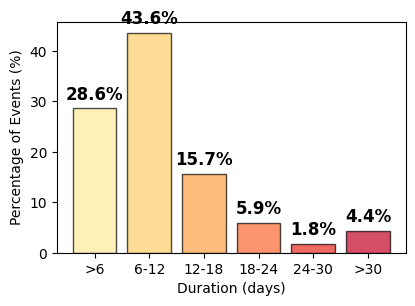

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Temporal_Events_Summary.xlsx"
data = pd.read_excel(file_path)

max_duration = data['Duration'].max()
bins = [0, 6, 12, 18, 24, 30, max_duration]
labels = ['>6', '6-12', '12-18', '18-24', '24-30', f'>30']

data['Duration Category'] = pd.cut(data['Duration'], bins=bins, labels=labels, include_lowest=True)

category_counts = data['Duration Category'].value_counts().sort_index()

category_percentages = (category_counts / category_counts.sum()) * 100

total_events = data.shape[0]
print(f"Total number of events: {total_events}")
print("\nPercentage of events in each category:")
print(category_percentages)

plt.figure(figsize=(4.5, 3))
colors = sns.color_palette("YlOrRd", len(category_percentages))
bars = plt.bar(category_percentages.index, category_percentages, color=colors, edgecolor='black', alpha=0.7)

for bar, percentage in zip(bars, category_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Duration (days)')
plt.ylabel('Percentage of Events (%)')
plt.xticks(rotation=0)
plt.show()


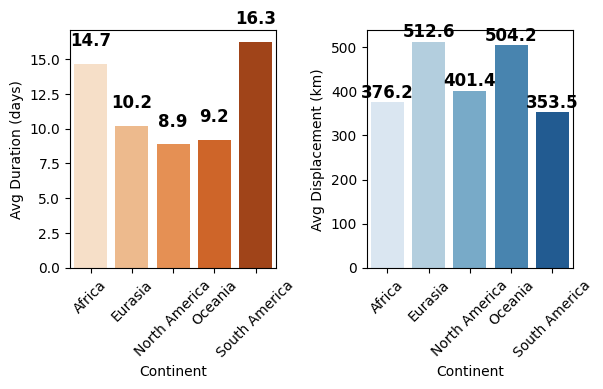

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Temporal_Events_Summary.xlsx"
data = pd.read_excel(file_path)

data.columns = data.columns.str.strip()

avg_duration = data.groupby('Continent')['Duration'].mean()
avg_displacement = data.groupby('Continent')['Distance'].mean()

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

sns.barplot(x=avg_duration.index, y=avg_duration.values, palette="Oranges", ax=axes[0])
axes[0].set_xlabel("Continent")
axes[0].set_ylabel("Avg Duration (days)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

for bar, value in zip(axes[0].patches, avg_duration.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

sns.barplot(x=avg_displacement.index, y=avg_displacement.values, palette="Blues", ax=axes[1])
axes[1].set_xlabel("Continent")
axes[1].set_ylabel("Avg Displacement (km)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

for bar, value in zip(axes[1].patches, avg_displacement.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\1799840161.py:196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


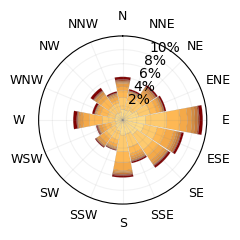

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\ross_poy_diagram_2_1.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\ross_poy_diagram_2_1.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\ross_poy_diagram_2_1.svg


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Event_Displacement_Direction.xlsx"

save_directory = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots"
os.makedirs(save_directory, exist_ok=True)

out_png = os.path.join(
    save_directory,
    "ross_poy_diagram_2_1.png"
)

out_pdf = os.path.join(
    save_directory,
    "ross_poy_diagram_2_1.pdf"
)

out_svg = os.path.join(
    save_directory,
    "ross_poy_diagram_2_1.svg"
)

df = pd.read_excel(file_path)


df["Direction"] = df["Direction"].astype(str)

max_duration = df["Duration"].max()

bounds = np.array([
    0, 3, 6, 9, 12, 15,
    18, 21, 24, 27, 30,
    max_duration + 1
], dtype=float)

colors = [
    "#ffeda0",
    "#feb24c",
    "#cd853f",
    "#800000"
]

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    colors,
    N=len(bounds) - 1
)

norm = mcolors.Normalize(
    vmin=0,
    vmax=len(bounds) - 2
)


df["Duration Category"] = pd.cut(
    df["Duration"],
    bins=bounds,
    labels=np.arange(len(bounds) - 1),
    include_lowest=True
)

aggregated_data = (
    df.groupby(
        ["Direction", "Duration Category"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
)


total_events = len(df)

percentage_data = (
    aggregated_data
    .divide(total_events)
    .fillna(0)
    * 100
)


directions = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

percentage_data = percentage_data.reindex(
    directions,
    fill_value=0
)

theta = np.linspace(
    0,
    2 * np.pi,
    len(directions),
    endpoint=False
)

fig, ax = plt.subplots(
    figsize=(2.5, 2.5),
    subplot_kw={"projection": "polar"},
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")


width = (
    2 * np.pi /
    len(directions) *
    0.95
)

bottom = np.zeros(
    len(directions)
)

for i, category in enumerate(
    percentage_data.columns
):

    heights = (
        percentage_data[category]
        .reindex(directions)
        .fillna(0)
        .to_numpy()
    )

    color = custom_cmap(
        norm(i)
    )

    ax.bar(
        theta,
        heights,
        width=width,
        bottom=bottom,
        color=color,
        edgecolor="grey",
        linewidth=0.1
    )

    bottom += heights

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_xticks(theta)

ax.set_xticklabels(
    directions,
    fontsize=9
)


ax.yaxis.grid(
    True,
    linestyle="-",
    color="gray",
    alpha=0.1
)

ax.xaxis.grid(
    True,
    linestyle="-",
    color="gray",
    alpha=0.1
)

yticks = ax.get_yticks()

ax.set_yticklabels(
    [
        f"{int(tick)}%"
        for tick in yticks
    ],
    fontsize=10,
    verticalalignment="bottom"
)

plt.tight_layout()

fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\1735004727.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Duration Category'] = pd.cut(subset['Duration'], bins=bounds, labels=np.arange(len(bounds)-1))
C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\1735004727.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_data = subset.groupby(['Direction', 'Duration Category']).size().unstack(fill_value=0)
C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\1735004727.py:57: UserWarning: set_ticklabels() should only be used with a fixe

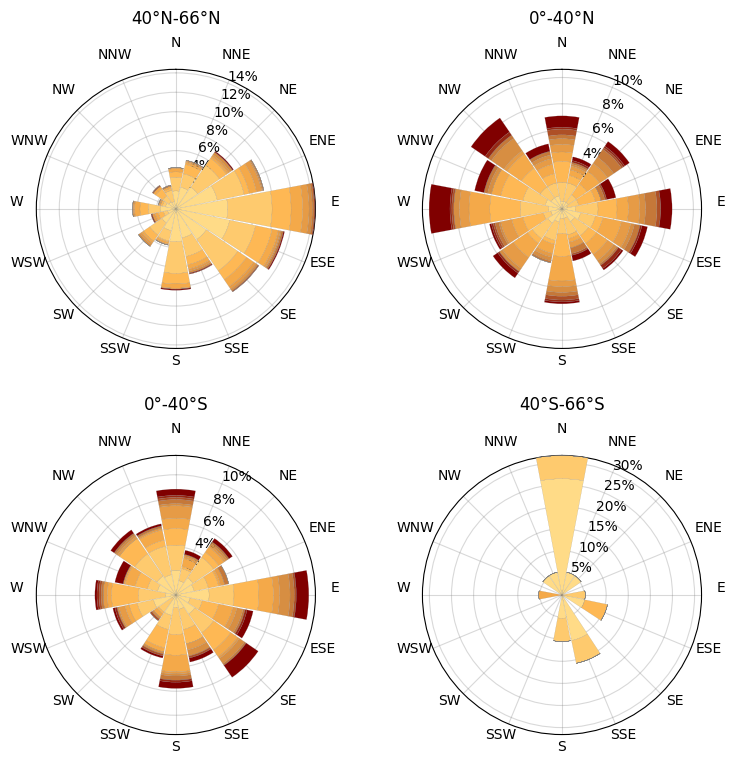

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm

file_path = 'D:\\PhD_Research\\Paper-3_CHDW_Migration\\Processing\\Processed Data\\Step_4_Event_Calculation\\Event_Observ\\Event_Displacement_Direction.xlsx'
df = pd.read_excel(file_path)

bounds = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, df['Duration'].max() + 1])
colors = ['#ffeda0', '#feb24c', '#cd853f', '#800000']
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=len(bounds)-1)
norm = Normalize(vmin=0, vmax=len(bounds)-2)

latitude_ranges = {
    '40°N-66°N': (40, 66),
    '0°-40°N': (0, 30),
    '0°-40°S': (-40, 0),
    '40°S-66°S': (-66, -40)
}

fig, axes = plt.subplots(2, 2, subplot_kw={'projection': 'polar'}, figsize=(8, 8))
axes = axes.flatten()

for i, (key, (lat_min, lat_max)) in enumerate(latitude_ranges.items()):
    subset = df[(df['Ending Latitude'] >= lat_min) & (df['Ending Latitude'] <= lat_max)]
    subset['Duration Category'] = pd.cut(subset['Duration'], bins=bounds, labels=np.arange(len(bounds)-1))
    aggregated_data = subset.groupby(['Direction', 'Duration Category']).size().unstack(fill_value=0)
    total_events = subset.shape[0]
    percentage_data = aggregated_data.divide(total_events).fillna(0) * 100

    directions = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
    theta = np.linspace(0, 2 * np.pi, len(directions), endpoint=False)
    percentage_data = percentage_data.reindex(directions).fillna(0)

    width = 2 * np.pi / len(directions) * 0.95
    bottom = np.zeros(len(directions))
    for category in percentage_data.columns:
        heights = percentage_data[category].reindex(directions).fillna(0)
        color = custom_cmap(norm(category))
        axes[i].bar(theta, heights, width=width, bottom=bottom, color=color, edgecolor='grey', linewidth=0.1, zorder=3)
        bottom += heights

    axes[i].yaxis.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    axes[i].xaxis.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    axes[i].set_xticks(theta)
    axes[i].set_xticklabels(directions, fontsize=10, verticalalignment='bottom')
    axes[i].set_theta_zero_location('N')
    axes[i].set_theta_direction(-1)

    yticks = axes[i].get_yticks()
    ytick_labels = [f'{int(tick)}%' for tick in yticks]
    axes[i].set_yticklabels(ytick_labels, verticalalignment='bottom', fontsize=10, zorder=10)  # Increased zorder to 10

    axes[i].set_title(f'{key}', fontsize=12, verticalalignment='bottom')

plt.tight_layout(pad=2.0)
save_path = 'D:\\PhD_Research\\Paper-3_CHDW_Migration\\Results\\Plots\\ross_poy_diagrams.png'
plt.savefig(save_path, transparent=True, dpi=300)
plt.show()


C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Amitesh\AppData\Local\Temp\ipykernel_33408\1610373107.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  text_label = f"{display_location} ({model_decade.params[1]:.2f}, p={mk_result.p:.4f})"
C:\Program 

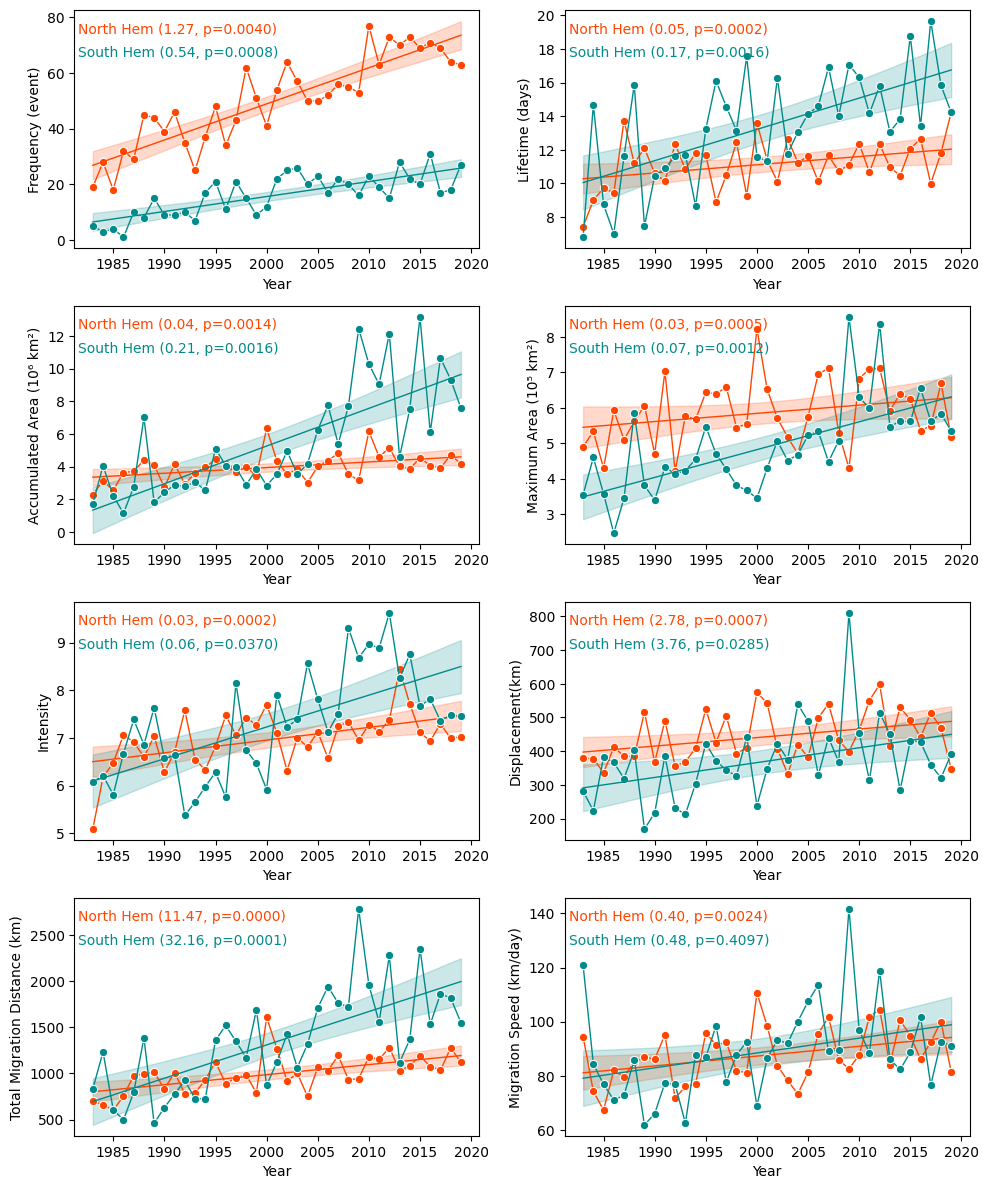

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import os
import pymannkendall as mk

file_path = r'D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Merged_Hemisphere_Yearly_Summary.xlsx'
df = pd.read_excel(file_path)

df['Decade'] = (df['Year'] // 10) * 10

def plot_with_trend(data, x, y_suffix, ax, title_prefix):

    for location, color in zip(['North', 'South'], ['orangered', 'darkcyan']):
        display_location = "North Hem" if location == 'North' else 'South Hem'
        column = title_prefix + '_' + location
 
        decade_data = data.groupby('Decade').agg({
            column: 'mean',
            x: 'mean'
        }).reset_index()

        X_decade = sm.add_constant(decade_data['Decade'])
        model_decade = sm.OLS(decade_data[column], X_decade).fit()
        predictions_decade = model_decade.predict(X_decade)

        X_year = sm.add_constant(data['Year'])
        model_year = sm.OLS(data[column], X_year).fit()
        predictions_year = model_year.predict(X_year)

        prediction_results = sm.regression.linear_model.OLSResults.get_prediction(model_year, X_year).summary_frame(alpha=0.05)
        iv_l = prediction_results['mean_ci_lower']
        iv_u = prediction_results['mean_ci_upper']

        sns.lineplot(x=x, y=column, data=data, ax=ax, marker='o', linestyle='-', lw=1, color=color)
        ax.plot(data[x], predictions_year, color=color, lw=1)
        ax.fill_between(data[x], iv_l, iv_u, color=color, alpha=0.2)

        mk_result = mk.yue_wang_modification_test(decade_data[column], alpha=0.05)

        offset = 0.95 if location == 'North' 
        text_label = f"{display_location} ({model_decade.params[1]:.2f}, p={mk_result.p:.4f})"
        
        ax.text(0.01, offset, text_label, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', color=color)

    ax.set_xlabel('Year')
    ax.set_ylabel(y_suffix)
    ax.legend(loc='upper left', frameon=False)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 12))

column_prefixes =  ['Frequency (event)', 'Lifetime (days)', 'Accumulated Area (10⁶ km²)',
                    'Maximum Area (10⁵ km²)', 'Intensity', 
                    'Displacement(km)', 'Total Migration Distance (km)', 'Migration Speed (km/day)']

for ax, prefix in zip(axes.flatten(), column_prefixes):
    plot_with_trend(df, 'Year', prefix, ax, prefix)

plt.tight_layout()

output_dir = r'D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots'
output_file = 'Comparative_Temporal_Characteristics2.png'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, output_file), dpi=300)

plt.show()
